# mSCA training diagnostics — arena

In [4]:
import os, importlib
import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

import msca, msca.models, msca.architectures, msca.utils, msca.evaluations
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca.evaluations)
importlib.reload(msca)
from msca import mSCA

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## Helper

In [16]:
import matplotlib.colors as mcolors

BEHAVIOR_COLORS = [
    "#e60000", "#ff9900", "#663300", "#33cc00", "#00cccc",
    "#0000ff", "#a366ff", "#ff00ff", "#888800", "#009999",
]
_REGION_SHADE = (0.6, 1.55)


def _shade(color, factor):
    r, g, b = mcolors.to_rgb(color)
    if factor <= 1.0:
        return (r * factor, g * factor, b * factor)
    t = min(factor - 1.0, 1.0)
    return (r + (1 - r) * t, g + (1 - g) * t, b + (1 - b) * t)

def plot_latents(
    latents: dict,
    filter_len: int,
    title: str,
    out_path: Path,
    n_cols: int = 10,
    seed: int = 0,
    row_labels: list | None = None,
) -> None:
    rng = np.random.default_rng(seed)
    regions = list(latents.keys())
    K = latents[regions[0]][0].shape[1]
    n_trials = len(latents[regions[0]])

    trial_idxs = rng.choice(n_trials, size=n_cols, replace=False)

    cat = [np.concatenate([np.asarray(t) for t in latents[r]], axis=0) for r in regions]
    lo = np.minimum.reduce([c.min(axis=0) for c in cat])
    hi = np.maximum.reduce([c.max(axis=0) for c in cat])

    fig, axs = plt.subplots(K, n_cols, figsize=(14, 8), squeeze=True)

    for col, trial in enumerate(trial_idxs):
        color = BEHAVIOR_COLORS[col % len(BEHAVIOR_COLORS)]
        for row in range(K):
            ax = axs[row, col]
            for ri, reg in enumerate(regions):
                shade = _shade(color, _REGION_SHADE[ri % len(_REGION_SHADE)])
                ax.plot(np.asarray(latents[reg][trial])[:, row], color=shade, lw=1.2)
            ax.set_ylim(lo[row] - 0.2, hi[row] + 0.2)
            if col > 0:
                ax.set_yticks([])
            elif row_labels is not None and row < len(row_labels):
                ax.set_ylabel(row_labels[row], fontsize=6, rotation=0,
                              ha="right", va="center", labelpad=18)
            if row < K - 1:
                ax.set_xticks([])
            ax.tick_params(labelsize=5)
            # if row == 0:
            #     ax.set_title(f"trial {trial}", fontsize=7, color=color)

    handles = [
        plt.Line2D([0], [0],
                   color=_shade("0.4", _REGION_SHADE[ri % len(_REGION_SHADE)]),
                   lw=2.0, label=reg)
        for ri, reg in enumerate(regions)
    ]
    fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)
    fig.suptitle(title, fontsize=10)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.show()


## 1. Load data

In [6]:
BEHAVIORS = [
    "climbdown", "climbup", "eating", "grooming", "jumpdown",
    "jumping", "rearing", "still", "walkflat", "walkgrid",
]

def _load_h5(filename):
    def _recurse(group):
        out = {}
        for key, item in group.items():
            out[key] = _recurse(item) if isinstance(item, h5py.Group) else item[()]
        return out
    with h5py.File(filename, "r") as f:
        return _recurse(f)

training_dataset = _load_h5("./data/arena_training_bin_size=10.h5")

X = {"cortex": [], "striatum": []}
behavior_labels = []

for beh_idx, behavior in enumerate(BEHAVIORS):
    v = training_dataset[behavior]
    n_trials = v["cortex"].shape[0]
    for region in X:
        X[region] += [v[region][i].astype("float32") for i in range(n_trials)]
    behavior_labels += [beh_idx] * n_trials

behavior_labels = np.array(behavior_labels)

print(f"cortex:   {len(X['cortex'])} trials, {X['cortex'][0].shape[1]} neurons, {X['cortex'][0].shape[0]} time pts")
print(f"striatum: {len(X['striatum'])} trials, {X['striatum'][0].shape[1]} neurons")
print(f"Behavior trial counts: { {b: int((behavior_labels == i).sum()) for i, b in enumerate(BEHAVIORS)} }")

cortex:   1046 trials, 81 neurons, 150 time pts
striatum: 1046 trials, 148 neurons
Behavior trial counts: {'climbdown': 68, 'climbup': 227, 'eating': 227, 'grooming': 97, 'jumpdown': 29, 'jumping': 11, 'rearing': 61, 'still': 51, 'walkflat': 41, 'walkgrid': 234}


## 2. Train or load mSCA

In [7]:
RESULTS_DIR = Path("./results")
MODEL_PATH  = RESULTS_DIR / "msca_nonlinearDecoder.pt"
LOSSES_PATH = str(RESULTS_DIR / "losses_nonlinearDecode.npz")

MSCA_KWARGS = dict(
    n_components=20, loss_func="Poisson", n_epochs=5000, post_hoc_epoch=-1,
    linear=False, lam_region=0.0, decoder_type="nonlinear",
    decoder_hidden_size=40, decoder_activation="tanh",
    cd_rate=0.5, cd_mode="both", filter_len=41,
    init="unique", decoder_init_mode="pca",
    sparsity_warmup_epochs=1000, balance_interval=1000,
)

if MODEL_PATH.exists() and Path(LOSSES_PATH).exists():
    print("Loading saved model and losses...")
    model = mSCA(**MSCA_KWARGS)
    model.load(str(MODEL_PATH), X)
    losses = mSCA.load_losses(LOSSES_PATH)
    checkpoint = torch.load(str(MODEL_PATH), weights_only=False)
    grad_dicts = checkpoint.get("train_gradient_dicts", None)
    lam_dicts  = checkpoint.get("train_lambda_dicts", None)
else:
    print("Training mSCA...")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    model, losses, lam_dicts, grad_dicts = mSCA(**MSCA_KWARGS).fit(X)
    model.save(str(MODEL_PATH))
    model.save_losses(losses, LOSSES_PATH)
    print(f"Saved model → {MODEL_PATH}")

Loading saved model and losses...
Using region-weights = {'cortex': 1.0192068083659944, 'striatum': 0.9815037013608887}
Using lam_sparse = adaptive
Using lam_orthog = 3795.38634868421
Using lam_region = 0.0


## 3. Loss curves

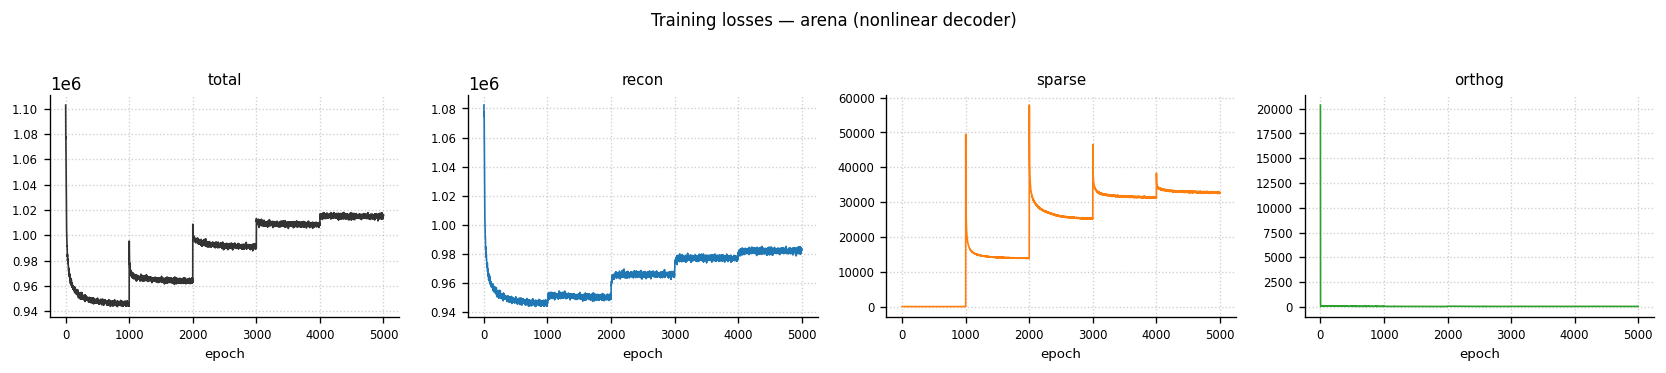

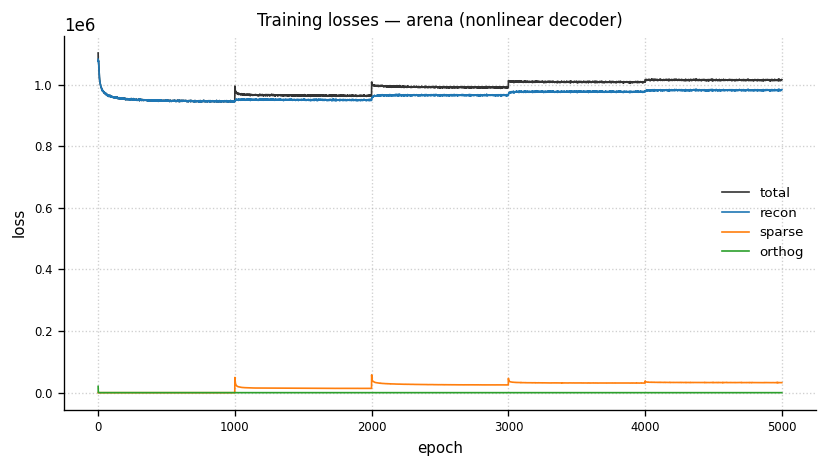

In [8]:
LOSS_KEYS   = ["total_loss", "reconstruction", "latent_sparsity", "orthogonality"]
LOSS_LABELS = ["total", "recon", "sparse", "orthog"]
COLORS = ["#333333", "#1f77b4", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(1, len(LOSS_KEYS), figsize=(14, 3))

for ax, key, label, color in zip(axes, LOSS_KEYS, LOSS_LABELS, COLORS):
    if key in losses:
        ax.plot(losses[key], color=color, lw=1)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("epoch", fontsize=8)
    ax.grid(ls=":", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)

plt.suptitle("Training losses — arena (nonlinear decoder)", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for key, label, color in zip(LOSS_KEYS, LOSS_LABELS, COLORS):
    if key in losses:
        ax.plot(losses[key], color=color, lw=1, label=label)
ax.set_xlabel("epoch", fontsize=9)
ax.set_ylabel("loss", fontsize=9)
ax.legend(frameon=False, fontsize=8)
ax.grid(ls=":", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=7)
ax.set_title("Training losses — arena (nonlinear decoder)", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "losses.pdf", bbox_inches="tight")
plt.show()

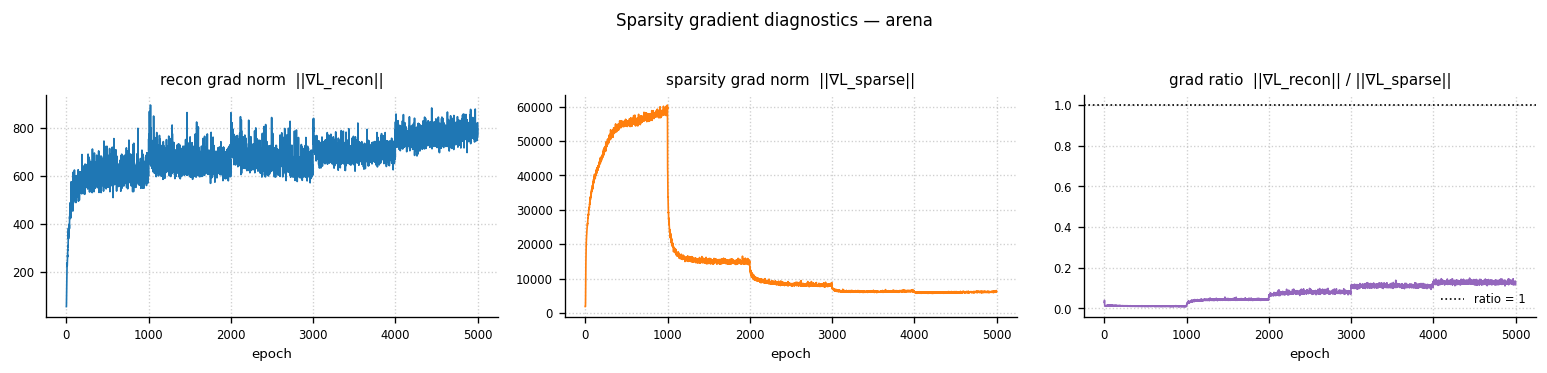

In [9]:
assert grad_dicts is not None, "grad_dicts not found — re-train to generate gradient history"

r_grad  = np.asarray(grad_dicts["r_grad"])
l1_grad = np.asarray(grad_dicts["l1_grad"])
ratio   = r_grad / (l1_grad + 1e-12)
epochs  = np.arange(len(r_grad))

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(epochs, r_grad,  color="#1f77b4", lw=1)
axes[0].set_title("recon grad norm  ||∇L_recon||", fontsize=9)

axes[1].plot(epochs, l1_grad, color="#ff7f0e", lw=1)
axes[1].set_title("sparsity grad norm  ||∇L_sparse||", fontsize=9)

axes[2].plot(epochs, ratio,   color="#9467bd", lw=1)
axes[2].axhline(1.0, color="k", ls=":", lw=1, label="ratio = 1")
axes[2].set_title("grad ratio  ||∇L_recon|| / ||∇L_sparse||", fontsize=9)
axes[2].legend(frameon=False, fontsize=7)

for ax in axes:
    ax.set_xlabel("epoch", fontsize=8)
    ax.grid(ls=":", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)

plt.suptitle("Sparsity gradient diagnostics — arena", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "grad_norms.pdf", bbox_inches="tight")
plt.show()

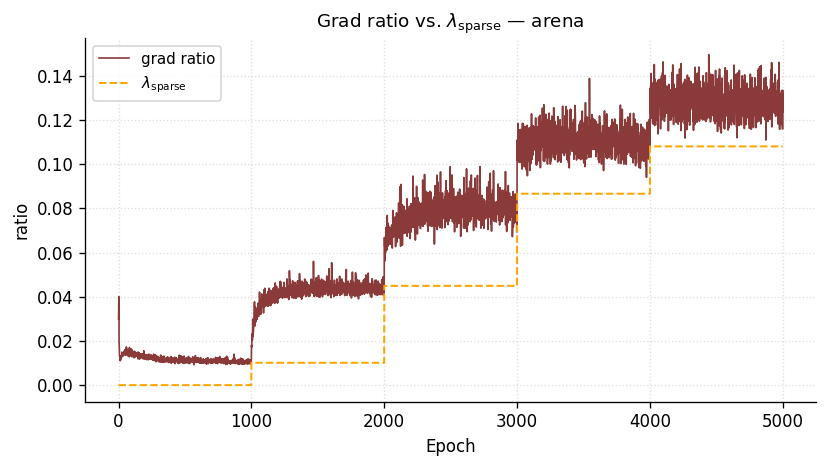

In [10]:
lam = np.asarray(lam_dicts["lam_sparse"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, ratio, color="#8B3A3A", lw=1,   label="grad ratio")
ax.plot(epochs, lam,   color="#FFA500", lw=1.2, label=r"$\lambda_{\rm sparse}$", linestyle="--")
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("ratio", fontsize=10)
ax.set_title(r"Grad ratio vs. $\lambda_{\rm sparse}$ — arena", fontsize=11)
ax.legend(frameon=True, fontsize=9)
ax.grid(ls=":", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Latents

In [12]:
Z = model.transform(X)



/var/folders/lm/hpfh84_s6p71hgkdg87dg0cm0000gn/T/ipykernel_73038/761034396.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


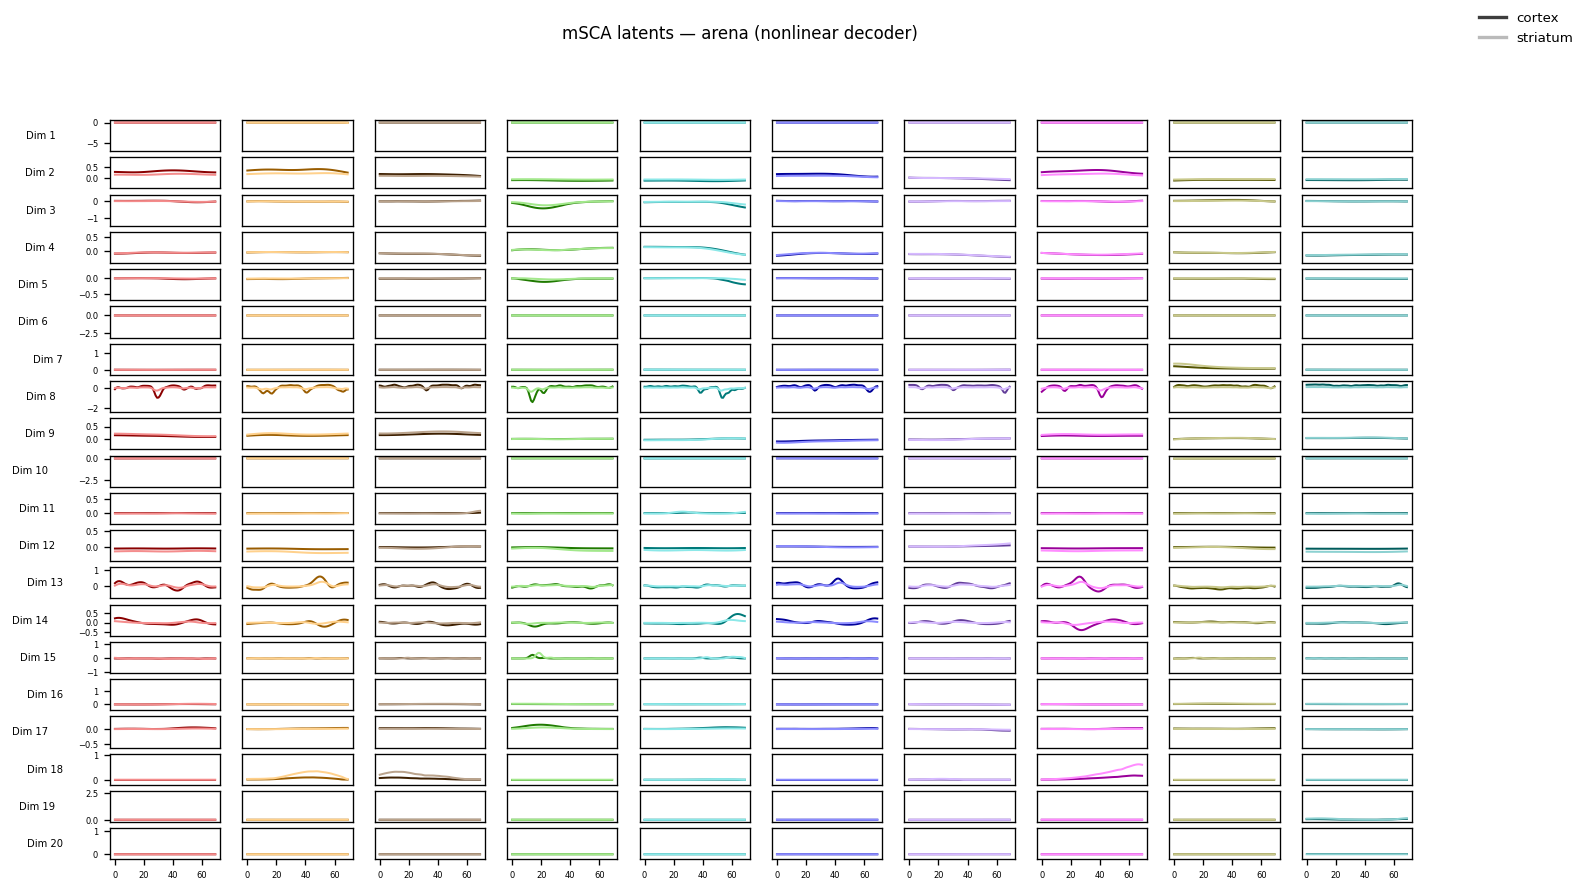

In [17]:
plot_latents(
    latents    = Z,
    filter_len = model.filter_len,
    title      = "mSCA latents — arena (nonlinear decoder)",
    out_path   = RESULTS_DIR / "latents.pdf",
    n_cols     = 10,
    seed       = 50,
    row_labels = [f"Dim {k+1}" for k in range(model.n_components)],
)
